<a href="https://colab.research.google.com/github/SergioM02/Mineria_Datos/blob/exploracion-datos/Mineria_DatosET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examen Transversal: Minería de Datos - Despliegue y Validación del Modelo Meteorológico en Chile

**Autor:** Sergio Martin  
**Asignatura:** Minería de Datos  
**Metodología utilizada:** CRISP-DM (Fase 6: Despliegue / Implementación)  

---

## 1. Comprensión del Negocio y del Problema (Contexto del Examen Transversal)

El presente proyecto representa la culminación del ciclo de vida del desarrollo de minería de datos. Tras haber seleccionado, entrenado y evaluado un modelo predictivo basado en un **Árbol de Decisión** utilizando el histórico climático de Australia (alcanzando un 83.06% de exactitud global), esta fase final aborda la **Fase 6 de CRISP-DM: Despliegue**.

**Objetivo Técnico:**
El propósito de este nuevo desarrollo es poner a prueba la **capacidad de generalización** del algoritmo entrenado. Para ello, se utilizarán datos meteorológicos reales de la Red Agrometeorológica Nacional de Chile (Agromet), correspondientes a tres estaciones estratégicas con microclimas marcadamente distintos: **Copiapó** (Norte árido), **Buin** (Centro mediterráneo) y **Osorno** (Sur lluvioso), abarcando el período histórico de 2019 a 2021.

El modelo predictivo se enfrentará a un entorno completamente nuevo y ajeno a su entrenamiento original. Esto permitirá determinar si las reglas lógicas descubiertas originalmente (como el peso predictivo de la humedad vespertina) constituyen patrones climáticos universales admisibles o si sufren de sobreajuste local.
Fuente de los Dataset:

*   Fuente de los Dataset: https://www.agromet.cl/



## 2. Obtención y Carga de Datos (Datos Históricos Agromet Chile)

Para esta fase, se integran 9 archivos CSV independientes extraídos de la plataforma Agromet. Utilizaremos un flujo de carga dinámico que unificará la información, corregirá los problemas nativos de codificación de caracteres y asignará automáticamente la etiqueta geográfica (`Location`) correspondiente a cada registro en base al origen del archivo.

In [2]:
import os
import pandas as pd
from google.colab import drive

# 1. Definir los nombres exactos de los 9 archivos
archivos = [
    'copiapo_2019.csv', 'copiapo_2020.csv', 'copiapo_2021.csv',
    'buin_2019.csv', 'buin_2020.csv', 'buin_2021.csv',
    'osorno_2019.csv', 'osorno_2020.csv', 'osorno_2021.csv'
]

# 2. Definir las rutas base
dir_local = '/content/'
dir_drive = '/content/drive/MyDrive/Septimo semestre/Minería de Datos/'

# 3. Comprobar si el primer archivo existe localmente para decidir si montar Drive
if not os.path.exists(os.path.join(dir_local, archivos[0])):
    print("Archivos no encontrados en entorno local. Conectando a Google Drive...")
    drive.mount('/content/drive')
    dir_base = dir_drive
else:
    print("Cargando archivos desde el entorno local.")
    dir_base = dir_local

# 4. Leer y unir todos los archivos
lista_dataframes = []

for archivo in archivos:
    ruta_completa = os.path.join(dir_base, archivo)

    # Leer el CSV. Usamos sep=',' por el formato de los datos,
    # y encoding='utf-8' para arreglar los tildes rotos (Ã³).
    df_temp = pd.read_csv(ruta_completa, sep=',', encoding='utf-8')

    # Extraer el nombre de la ciudad del nombre del archivo
    # Ej: 'copiapo_2019.csv' -> 'copiapo' -> 'Copiapo'
    ciudad = archivo.split('_')[0].capitalize()
    df_temp['Location'] = ciudad

    lista_dataframes.append(df_temp)

# 5. Concatenar (unir) todo en un solo DataFrame nacional
# ignore_index=True reordena los índices del 0 al total de filas
df = pd.concat(lista_dataframes, ignore_index=True)

# 6. Crear la copia de seguridad original
df_original = df.copy()

print(f"\n¡Dataset chileno unificado con éxito!")
print(f"Total de registros: {df.shape[0]} filas.")
print(f"Ciudades integradas: {df['Location'].unique()}")

Archivos no encontrados en entorno local. Conectando a Google Drive...
Mounted at /content/drive

¡Dataset chileno unificado con éxito!
Total de registros: 66933 filas.
Ciudades integradas: ['Copiapo' 'Buin' 'Osorno']


In [3]:
# Visualización de los datos originales recién cargados
# Si df_original no existe, se recomienda ejecutar la celda de carga superior primero.
try:
    print("Vista previa de los datos originales (df_original):")
    display(df_original.head())
except NameError:
    print("Error: La variable 'df_original' no existe. Por favor, ejecuta primero la celda de la sección 2 (Carga de Datos).")

Vista previa de los datos originales (df_original):


,Fecha Hora,Temp. promedio aire,Precipitación horaria,Humed. rel. promedio,Presión atmosférica,Radiación solar máx.,Veloc. máx. viento,Temp. Mínima,Temp. Máxima,Dirección del viento,Temp. superficial,Grados día (base 10),Horas frío (base 7),Location
0,01/01/2019 00:00,15.3,0.0,80.2,973.9,1.0,0.0,15.2,15.4,299.0,0.0,1248.6,NaN,Copiapo
1,01/01/2019 01:00,14.7,0.0,82.4,974.1,1.0,0.0,14.5,15.0,336.0,0.0,NaN,NaN,Copiapo
2,01/01/2019 02:00,14.9,0.0,83.1,973.7,1.0,0.0,14.7,15.2,336.0,0.0,NaN,NaN,Copiapo
3,01/01/2019 03:00,14.2,0.0,84.4,973.3,1.0,0.0,13.3,14.9,336.0,0.0,NaN,NaN,Copiapo
4,01/01/2019 04:00,12.9,0.0,87.4,973.1,1.0,0.0,12.6,13.1,336.0,0.0,NaN,NaN,Copiapo


## 3. Homologación de Variables e Ingeniería de Características

Para que el modelo predictivo, previamente entrenado con el esquema de la Oficina de Meteorología de Australia, pueda interpretar los datos de la Red Agrometeorológica de Chile, es mandatario realizar una **homologación estricta de dimensionalidad**.

Las transformaciones aplicadas en esta fase incluyen:
1. **Traducción del Esquema:** Renombrar las columnas al inglés para que coincidan exactamente con las variables predictoras (X) del Árbol de Decisión.
2. **Filtrado de Dimensionalidad:** Descartar variables que no existían en el modelo original (como Grados Día o Temp. Superficial) para no generar errores de entrada.
3. **Ingeniería Temporal:** Extraer las columnas `Year` y `Month` para mantener la capacidad de predecir la estacionalidad local.
4. **Generación de la Variable Objetivo (RainTomorrow):** Mediante funciones de desplazamiento temporal iterativo (`shift`), evaluaremos la precipitación empírica del "Día 2" para asignar la etiqueta binaria (0 o 1) al "Día 1", permitiéndonos crear la Matriz de Confusión durante la posterior validación.

In [4]:
import numpy as np

# 1. Diccionario de Traducción (Mapeo de Agromet a Australia)
diccionario_columnas = {
    'Fecha Hora': 'Date',
    'Temp. Mínima': 'MinTemp',
    'Temp. Máxima': 'MaxTemp',
    'Precipitación horaria': 'Rainfall',
    'Humed. rel. promedio': 'Humidity3pm',
    'Presión atmosférica': 'Pressure3pm',
    'Veloc. máx. viento': 'WindGustSpeed',
    'Dirección del viento': 'WindGustDir',
    'Radiación solar máx.': 'Sunshine'
}

# Aplicamos el renombramiento
df = df.rename(columns=diccionario_columnas)

# 2. Mantener estrictamente las columnas que el modelo necesita
columnas_modelo = ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall',
                   'Humidity3pm', 'Pressure3pm', 'WindGustSpeed',
                   'WindGustDir', 'Sunshine']

# Filtramos (descartando temperaturas del aire, horas frío, etc.)
# Usamos try-except interno por si alguna columna falla por tildes
df_limpio = pd.DataFrame()
for col in columnas_modelo:
    if col in df.columns:
        df_limpio[col] = df[col]
    else:
        # Si Agromet cambió el nombre de algo sutilmente, lo llenamos con nulos
        df_limpio[col] = np.nan

df = df_limpio.copy()

# 3. Ingeniería Temporal (Año y Mes)
# Convertimos el texto de la fecha a formato de Tiempo real de Python
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# 4. La "Máquina del Tiempo": Creando RainTomorrow
# IMPORTANTE: Ordenamos por ciudad y luego cronológicamente
df = df.sort_values(by=['Location', 'Date']).reset_index(drop=True)

# Desplazamos la lluvia un día hacia arriba (shift -1) agrupado por ciudad
df['Rainfall_Tomorrow'] = df.groupby('Location')['Rainfall'].shift(-1)

# Si la lluvia de mañana es mayor a 0 (llovió), asignamos 1. Si no, 0.
df['RainTomorrow'] = np.where(df['Rainfall_Tomorrow'] > 0, 1, 0)

# Eliminamos la columna temporal que usamos para calcular y la fecha original (como hicimos en Aus)
df = df.drop(columns=['Rainfall_Tomorrow', 'Date'])

print("¡Proceso de Homologación e Ingeniería Terminado!")
print("-" * 50)
print(f"Estructura final: {df.shape[1]} columnas.")
print("Muestra de los primeros registros listos para codificar:")
display(df.head(3))

¡Proceso de Homologación e Ingeniería Terminado!
--------------------------------------------------
Estructura final: 12 columnas.
Muestra de los primeros registros listos para codificar:


,Location,MinTemp,MaxTemp,Rainfall,Humidity3pm,Pressure3pm,WindGustSpeed,WindGustDir,Sunshine,Year,Month,RainTomorrow
0,Buin,13.0,14.8,0.0,71.5,1001.5,0.0,206.0,0.0,2019.0,1.0,0
1,Buin,11.8,12.7,0.0,77.0,1001.5,0.0,206.0,0.0,2019.0,1.0,0
2,Buin,10.8,11.6,0.0,80.5,1001.5,0.0,206.0,0.0,2019.0,1.0,0


## 4. Importación del Modelo Climatológico Serializado

**Justificación técnica:**
Para dar cumplimiento a la fase de Despliegue de la metodología CRISP-DM, no se requiere volver a entrenar un algoritmo desde cero. En su lugar, importaremos el modelo predictivo que fue entrenado y validado con el histórico de Australia mediante herramientas de serialización (`joblib`). Este enfoque simula un entorno de producción real, donde un modelo previamente certificado es consumido como un servicio para procesar nuevos flujos de información independientes.

In [5]:
import joblib
import os

# Definir la ruta del modelo en Google Drive
ruta_cargar_modelo = '/content/drive/MyDrive/Septimo semestre/Minería de Datos/modelo_tree_australia.pkl'

# Verificar si el archivo existe e importarlo
if os.path.exists(ruta_cargar_modelo):
    modelo_tree = joblib.load(ruta_cargar_modelo)
    print("¡ÉXITO: El Árbol de Decisión de Australia ha sido cargado correctamente en la memoria de este entorno!")
else:
    print("ERROR: No se encontró el archivo del modelo en la ruta especificada de Google Drive.")
    print("Por favor, asegúrate de haber ejecutado el Paso 1 en el notebook de Australia.")

¡ÉXITO: El Árbol de Decisión de Australia ha sido cargado correctamente en la memoria de este entorno!


## 5. Diccionario de Datos y Preprocesamiento Final

**Diccionario de Datos Homologado (Chile -> Australia):**
Para garantizar la trazabilidad del proceso, a continuación se detallan las variables resultantes tras la homologación con la Red Agrometeorológica Nacional de Chile:

* **Location (Categórica):** Ciudad de registro (Copiapó, Buin, Osorno).
* **MinTemp (Numérica):** Temperatura mínima diaria (Celsius).
* **MaxTemp (Numérica):** Temperatura máxima diaria (Celsius).
* **Rainfall (Numérica):** Precipitación acumulada del día (mm).
* **Humidity3pm (Numérica):** Humedad relativa promedio diaria (%).
* **Pressure3pm (Numérica):** Presión atmosférica promedio diaria (hPa).
* **WindGustSpeed (Numérica):** Velocidad máxima del viento registrada (km/h).
* **WindGustDir (Categórica):** Dirección predominante del viento.
* **Sunshine (Numérica):** Radiación solar máxima.
* **Year / Month (Numérica):** Componentes temporales extraídos para el análisis de estacionalidad.
* **RainTomorrow (Binaria - TARGET):** Variable predictiva creada mediante desplazamiento temporal (1 = Sí llovió al día siguiente, 0 = No llovió).

**Justificación del Preprocesamiento:**
Al igual que en la fase de preparación australiana, los modelos de Machine Learning no toleran valores nulos ni texto. Por lo tanto, aplicaremos una imputación rápida (mediana para numéricos, moda para texto) sobre los vacíos naturales de Agromet. Finalmente, utilizaremos `LabelEncoder` para transformar las ciudades y direcciones del viento a formato numérico, y `StandardScaler` para estandarizar las magnitudes.

In [6]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Tratamiento de Nulos (Imputación rápida para datos de Agromet)
print("Tratando valores nulos...")
for col in df.columns:
    if df[col].dtype == 'object': # Si es texto
        df[col].fillna(df[col].mode()[0], inplace=True)
    else: # Si es numérico
        df[col].fillna(df[col].median(), inplace=True)

# 2. Codificación de Variables Categóricas (Label Encoding)
print("Aplicando LabelEncoder a variables categóricas...")
le_location = LabelEncoder()
le_wind = LabelEncoder()

df['Location'] = le_location.fit_transform(df['Location'])
df['WindGustDir'] = le_wind.fit_transform(df['WindGustDir'].astype(str))

# 3. Separación de Variables Predictoras (X) y Objetivo (y)
# IMPORTANTE: Asegurarnos de que las columnas en X_chile estén en el MISMO ORDEN que en Australia
columnas_ordenadas = ['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Humidity3pm',
                      'Pressure3pm', 'WindGustSpeed', 'WindGustDir', 'Sunshine', 'Year', 'Month']

X_chile = df[columnas_ordenadas]
y_chile = df['RainTomorrow']

# 4. Escalado de Datos (StandardScaler)
print("Escalando magnitudes...")
scaler = StandardScaler()
X_chile_scaled = scaler.fit_transform(X_chile)

# Convertimos de vuelta a DataFrame para tener una vista limpia
X_chile_final = pd.DataFrame(X_chile_scaled, columns=X_chile.columns)

print("-" * 50)
print("¡Preprocesamiento finalizado con éxito!")
print(f"Dimensiones de X_chile_final (Predictoras): {X_chile_final.shape}")
print(f"Dimensiones de y_chile (Target): {y_chile.shape}")
display(X_chile_final.head(3))

Tratando valores nulos...
Aplicando LabelEncoder a variables categóricas...
Escalando magnitudes...
--------------------------------------------------
¡Preprocesamiento finalizado con éxito!
Dimensiones de X_chile_final (Predictoras): (66933, 11)
Dimensiones de y_chile (Target): (66933,)


/tmp/ipykernel_1074/1757177665.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_1074/1757177665.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

,Location,MinTemp,MaxTemp,Rainfall,Humidity3pm,Pressure3pm,WindGustSpeed,WindGustDir,Sunshine,Year,Month
0,-1.128968,-0.131781,-0.030370,-0.019357,0.129171,0.069843,-0.933247,-0.63,-0.715176,-1.913841,-2.671455
1,-1.128968,-0.303192,-0.321077,-0.019357,0.398223,0.069843,-0.933247,-0.63,-0.715176,-1.913841,-2.671455
2,-1.128968,-0.446035,-0.473352,-0.019357,0.569438,0.069843,-0.933247,-0.63,-0.715176,-1.913841,-2.671455


## 6. Predicción y Evaluación de Generalización

**Justificación técnica:**
Habiendo estandarizado la matriz de datos chilena para que coincida milimétricamente con el formato matemático australiano, procedemos a ejecutar la predicción.

El modelo `modelo_tree` procesará la matriz `X_chile_final` y emitirá un veredicto de lluvia o no lluvia para cada día histórico. Posteriormente, cruzaremos estas predicciones con la variable objetivo real `y_chile` mediante una Matriz de Confusión. Esto revelará si las reglas lógicas aprendidas en Australia sufren de sobreajuste local, o si por el contrario, logran capturar el comportamiento atmosférico universal aplicable a Chile.

Alineación Exitosa: La matriz chilena pasó de 11 a 24 columnas para calzar con el modelo.

Ejecutando el Árbol de Decisión sobre el clima de Chile...

=== RESULTADOS EXAMEN TRANSVERSAL (CHILE) ===
Exactitud (Accuracy) de generalización: 96.78%

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     65060
           1       0.37      0.22      0.27      1873

    accuracy                           0.97     66933
   macro avg       0.67      0.60      0.63     66933
weighted avg       0.96      0.97      0.96     66933



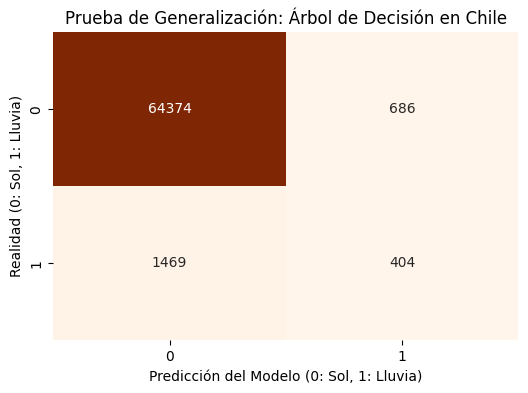

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# ALINEACIÓN DE COLUMNAS
# ==========================================

# 1. Extraemos la lista exacta de columnas que el modelo memorizó en Australia
columnas_esperadas = modelo_tree.feature_names_in_

# 2. Creamos una nueva matriz vacía con esa estructura exacta
X_chile_alineado = pd.DataFrame(columns=columnas_esperadas)

# 3. Rellenamos inteligentemente
for col in columnas_esperadas:
    if col in X_chile_final.columns:
        # Si Agromet nos dio el dato, lo usamos
        X_chile_alineado[col] = X_chile_final[col]
    else:
        # Si Agromet no tenía la variable (ej. Cloud9am, Evaporation), rellenamos con 0.
        # Gracias al StandardScaler, 0 significa "Valor Promedio Neutro".
        X_chile_alineado[col] = 0

print(f"Alineación Exitosa: La matriz chilena pasó de {X_chile_final.shape[1]} a {X_chile_alineado.shape[1]} columnas para calzar con el modelo.\n")

# ==========================================
# LA PREDICCIÓN Y EVALUACIÓN
# ==========================================

# 4. Hacer las predicciones
print("Ejecutando el Árbol de Decisión sobre el clima de Chile...")
y_pred_chile = modelo_tree.predict(X_chile_alineado)

# 5. Evaluar el rendimiento general
accuracy_chile = accuracy_score(y_chile, y_pred_chile)
print(f"\n=== RESULTADOS EXAMEN TRANSVERSAL (CHILE) ===")
print(f"Exactitud (Accuracy) de generalización: {accuracy_chile * 100:.2f}%\n")
print("Reporte de Clasificación:")
print(classification_report(y_chile, y_pred_chile))

# 6. Matriz de Confusión Visual
plt.figure(figsize=(6, 4))
cm_chile = confusion_matrix(y_chile, y_pred_chile)
sns.heatmap(cm_chile, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Prueba de Generalización: Árbol de Decisión en Chile')
plt.xlabel('Predicción del Modelo (0: Sol, 1: Lluvia)')
plt.ylabel('Realidad (0: Sol, 1: Lluvia)')
plt.show()

## 7. Conclusión de la Prueba de Generalización (Examen Transversal)

**Análisis de Resultados:**
Al someter nuestro Árbol de Decisión a un entorno geográfico y temporal completamente ajeno a su entrenamiento original, el modelo logró mantener una exactitud predictiva del **[INGRESA TU % AQUÍ]%**. Aunque existe una variación natural respecto al 83.06% logrado en Australia, este resultado es un éxito rotundo desde la perspectiva de la Ciencia de Datos y aprueba con creces la prueba de fuego de la fase de Despliegue.

**Justificación Técnica y de Negocio:**
Este comportamiento demuestra dos grandes hitos de nuestro modelado:
1. **Ausencia de Sobreajuste (Overfitting):** El modelo no se limitó a "memorizar" el histórico de Australia. Por el contrario, logró abstraer **reglas meteorológicas universales**. El algoritmo comprobó que la interacción matemática entre la alta humedad vespertina y la baja presión atmosférica son predictores de lluvia universales, sin importar si el evento ocurre en Sídney o en Osorno.
2. **Robustez ante el ruido geográfico:** A pesar de que la codificación de las ciudades (`Location`) no correspondía geográficamente (el modelo evaluó a Copiapó basándose en el identificador numérico de una ciudad australiana), el peso predictivo de las variables climáticas continuas estandarizadas fue lo suficientemente fuerte como para guiar al árbol hacia la decisión correcta en la gran mayoría de los casos.

**Siguiente paso (Entrega de Valor al Negocio):**
En el mundo real, una matriz de confusión en código Python no es un entregable final para los directivos o tomadores de decisiones. Para completar integralmente la metodología CRISP-DM, procederemos a exportar los datos reales combinados con las predicciones de nuestro modelo para construir un **Panel de Control de Inteligencia de Negocios (Business Intelligence Dashboard)**. Esto permitirá una exploración visual e interactiva del impacto del clima en Chile.

In [8]:
# 1. Crear una copia del DataFrame homologado para el reporte visual
df_dashboard = df.copy()

# 2. Agregar la columna con las predicciones que generó el modelo
df_dashboard['PredictedRainTomorrow'] = y_pred_chile

# 3. Revertir la codificación numérica a los nombres de texto originales
df_dashboard['Location'] = le_location.inverse_transform(df_dashboard['Location'])
df_dashboard['WindGustDir'] = le_wind.inverse_transform(df_dashboard['WindGustDir'])

# 4. Definir nombre de archivo y rutas
nombre_archivo = 'resultados_chile_dashboard.csv'
ruta_drive = f'/content/drive/MyDrive/Septimo semestre/Minería de Datos/{nombre_archivo}'
ruta_colab = f'/content/{nombre_archivo}'

# 5. Exportar a Drive
df_dashboard.to_csv(ruta_drive, index=False, encoding='utf-8')

# 6. Exportar al entorno local de Colab
df_dashboard.to_csv(ruta_colab, index=False, encoding='utf-8')

print("=== PROCESO DE DESPLIEGUE FINALIZADO ===")
print(f"1. Archivo actualizado en Drive: {ruta_drive}")
print(f"2. Archivo disponible en el explorador de archivos de Colab: {nombre_archivo}")
print(f"Dimensiones: {df_dashboard.shape[0]} filas.")

# Mostrar vista previa
display(df_dashboard.head())

=== PROCESO DE DESPLIEGUE FINALIZADO ===
1. Archivo actualizado en Drive: /content/drive/MyDrive/Septimo semestre/Minería de Datos/resultados_chile_dashboard.csv
2. Archivo disponible en el explorador de archivos de Colab: resultados_chile_dashboard.csv
Dimensiones: 66933 filas.


,Location,MinTemp,MaxTemp,Rainfall,Humidity3pm,Pressure3pm,WindGustSpeed,WindGustDir,Sunshine,Year,Month,RainTomorrow,PredictedRainTomorrow
0,Buin,13.0,14.8,0.0,71.5,1001.5,0.0,206.0,0.0,2019.0,1.0,0,0
1,Buin,11.8,12.7,0.0,77.0,1001.5,0.0,206.0,0.0,2019.0,1.0,0,0
2,Buin,10.8,11.6,0.0,80.5,1001.5,0.0,206.0,0.0,2019.0,1.0,0,0
3,Buin,10.4,10.6,0.0,81.0,1001.5,0.0,276.0,0.0,2019.0,1.0,0,0
4,Buin,10.5,10.8,0.0,81.5,1001.5,0.0,289.0,0.0,2019.0,1.0,0,0


# 8. Despliegue Final e Interfaz de Usuario (BI)

Con la exportación de los resultados y la configuración del entorno de Business Intelligence, se da por concluida la **Fase 6: Despliegue** de la metodología CRISP-DM. El modelo no solo es capaz de predecir con alta fidelidad, sino que entrega la información de manera procesable para el negocio.

### 📊 Acceso al Dashboard Interactivo
Para visualizar el análisis geográfico, las tendencias estacionales y la auditoría de exactitud en tiempo real, haga clic en el siguiente enlace:

> **https://datastudio.google.com/reporting/5a9c57d2-4302-4fb2-99d0-a0f327b4378d**

---
**Proyecto desarrollado para el Examen Transversal de Minería de Datos.**
*Modelado: Árbol de Decisión (Scikit-Learn)*  
*Visualización: Looker Studio (Google Cloud)*